In [2]:
import numpy as np
from pylab import gca
import numpy as np
import math
from tqdm import tqdm
import torch
import torchvision
import torch.nn as nn
from torch.utils import data
from torchvision import transforms
from torchvision.utils import save_image
from torchvision.datasets import MNIST
import torchvision.transforms.functional as TF
from torch.optim import lr_scheduler
import time
import os
import cv2
import pdb
from PIL import Image
import matplotlib.pyplot as plt 

In [3]:
def frame_tick(frame_width = 2, tick_width = 1.5):
    ax = gca()
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(frame_width)
    plt.tick_params(direction = 'in', 
                    width = tick_width)
def legend(location = 'best', fontsize = 8):
        plt.legend(loc = location, fontsize = fontsize, frameon = False)

In [4]:
parent_directory = '/home/oogoke/SRdataset/testinclonger_epoch_srdiff_attempt_5_add_embed_mean_corrected_5eneg5/'
epoch = 2
data_1 = np.load(os.path.join(parent_directory, 'all_data-{}.npz').format(epoch))


In [5]:
data_1.files

['res',
 'hr',
 'true_lr',
 'upscaled_lr',
 'sampled',
 'mean_lrs',
 'std_lrs',
 'mean_resid',
 'std_resid']

In [6]:
std_resid = data_1['std_resid']
mean_resid = data_1['mean_resid']
std_lrs = data_1['std_lrs']
mean_lrs = data_1['mean_lrs']
sampled_data = data_1['sampled']
lr_data = data_1['upscaled_lr']
input_data = data_1['true_lr']
residuals = sampled_data[:,0]*std_resid + mean_resid

true_residual = data_1['res']*std_resid + mean_resid
true_lrs = input_data*std_lrs + mean_lrs
hr = data_1['hr']
generated_hr = lr_data + residuals

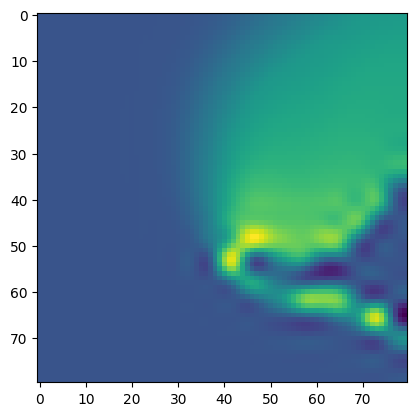

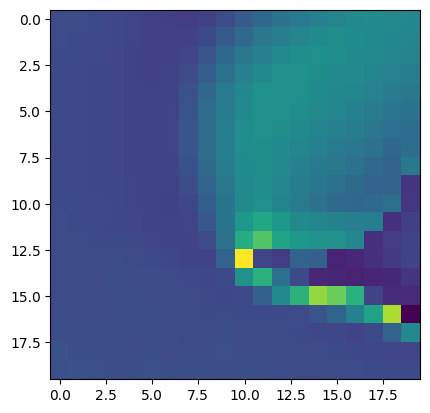

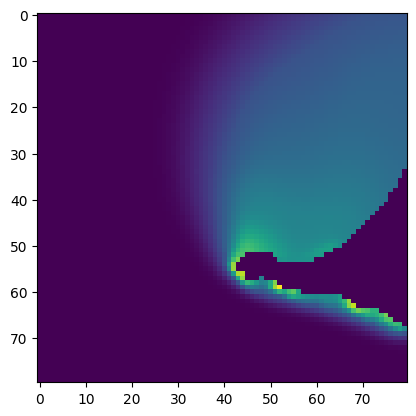

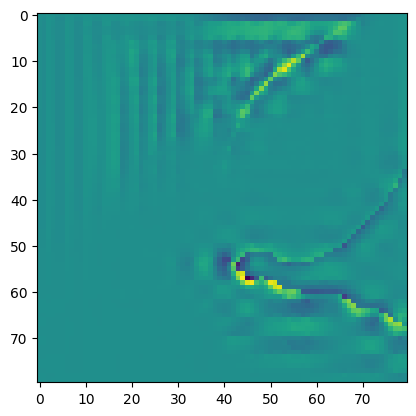

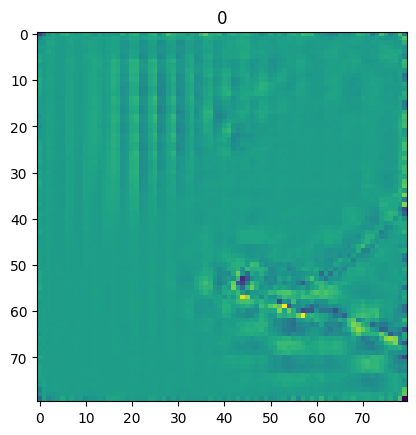

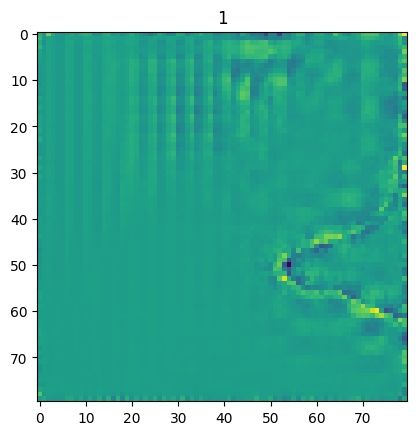

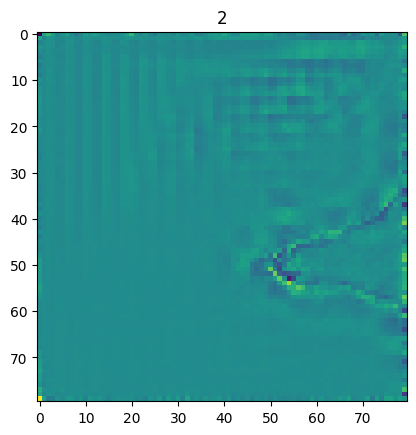

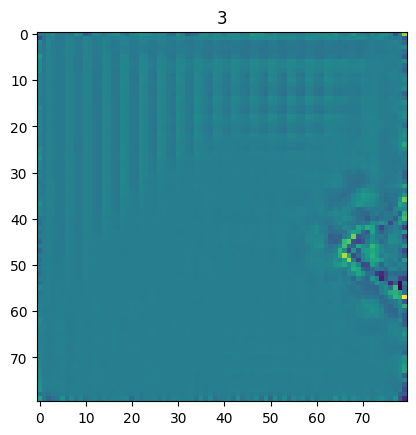

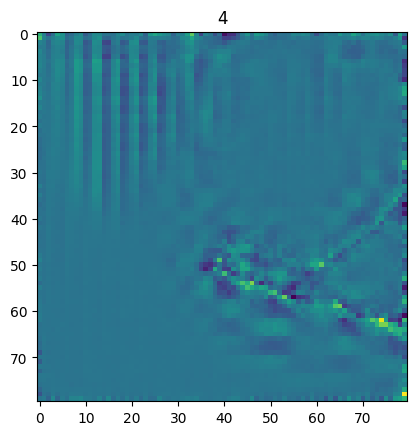

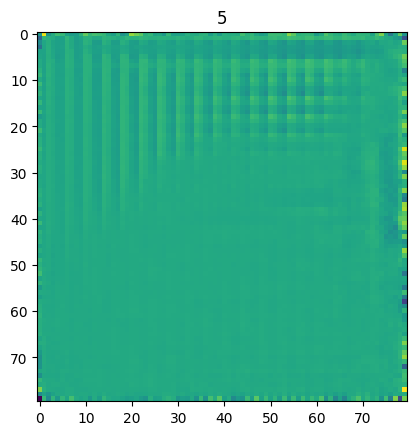

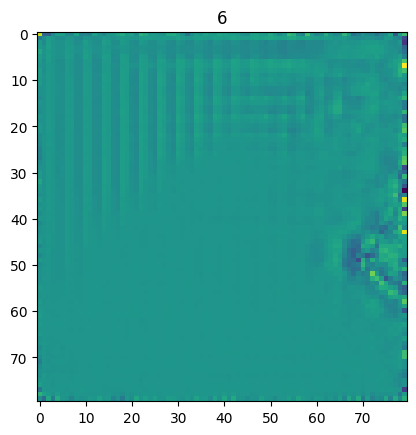

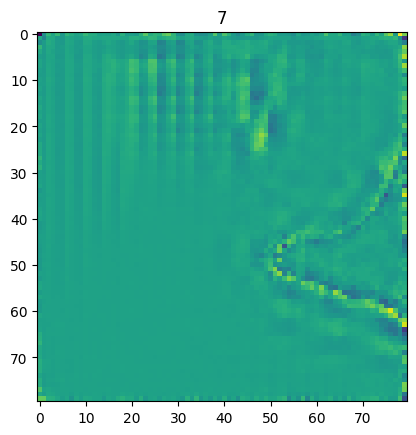

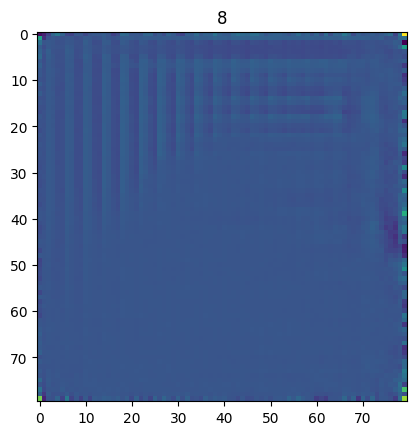

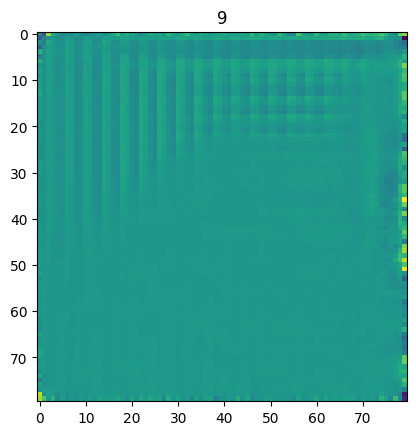

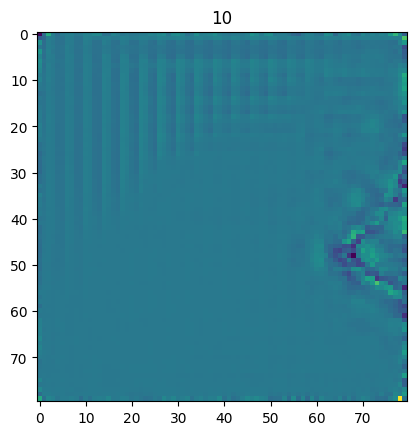

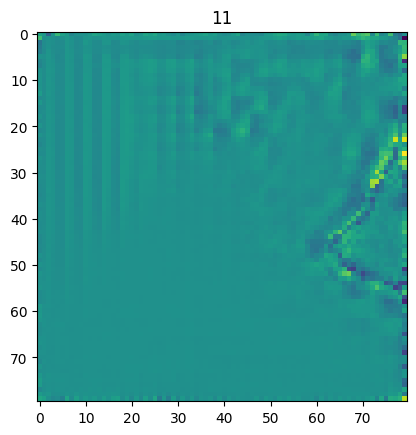

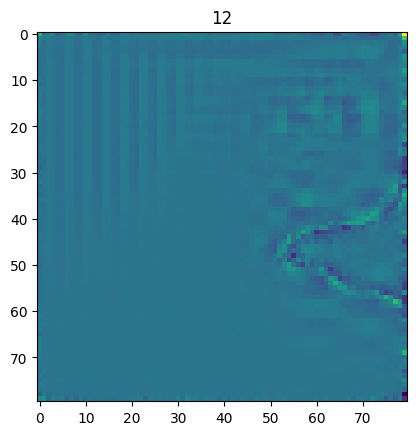

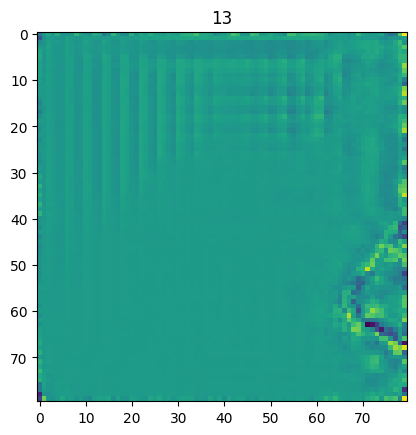

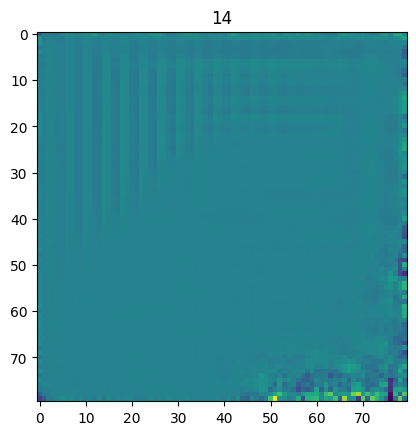

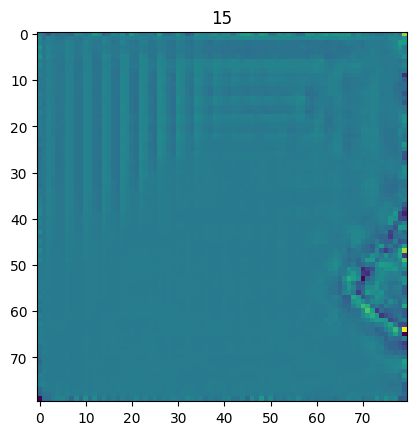

In [36]:
plt.imshow(data_1['upscaled_lr'][0])
plt.show()
plt.imshow(data_1['true_lr'][0])
plt.show()
plt.imshow(data_1['hr'][0])
plt.show()
plt.imshow(data_1['res'][0])
plt.show()
for i in range(16):
    plt.title(i)
    plt.imshow(data_1['sampled'][i,0])
    plt.show()

In [4]:
def plot_temp_images_srdiff(data, max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Lanczos'):
# max_temp = 5000
# min_temp = 293
# dpi = 90
# scaling_factor = 1.5
# method = 'Lanczos'

    std_resid = data['std_resid']
    mean_resid = data['mean_resid']
    std_lrs = data['std_lrs']
    mean_lrs = data['mean_lrs']
    sampled_data = data['sampled']
    lr_data = data['upscaled_lr']
    input_data = data['true_lr']
    residuals = sampled_data[:,0]*std_resid + mean_resid

    true_residual = data['res']*std_resid + mean_resid
    true_lrs = input_data*std_lrs + mean_lrs
    hr = data['hr']

    generated_hr = lr_data + residuals
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)
    plt.imshow((true_lrs[0]).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] Low Resolution, {} downscaling'.format('Train', method), fontsize = 10)
    plt.show()
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.imshow((hr[0]).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] High Resolution'.format('Train'), fontsize = 10)
    plt.show()

    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.imshow((generated_hr[0]).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] Generated High Resolution'.format('Train'), fontsize = 10)
    plt.show()

    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.imshow((residuals[0]).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] Residual Between HR and LR, Sampled'.format('Train'), fontsize = 10)
    plt.show()
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.imshow((true_residual[0]).T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title('[{} Data] Residual Between HR and LR, GT'.format('Train'), fontsize = 10)
    plt.show()

In [5]:
def plot_temp_lines_srdiff(data, max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Lanczos'):

    std_resid = data_1['std_resid']
    mean_resid = data_1['mean_resid']
    std_lrs = data_1['std_lrs']
    mean_lrs = data_1['mean_lrs']
    sampled_data = data_1['sampled']
    lr_data = data_1['upscaled_lr']
    input_data = data_1['true_lr']
    residuals = sampled_data[:,0]*std_resid + mean_resid

    true_residual = data_1['res']*std_resid + mean_resid
    true_lrs = input_data*std_lrs + mean_lrs
    hr = data_1['hr']
    generated_hr = lr_data + residuals
    # dpi = 150
    # scaling_factor = 1.5
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.title(r'SRDiff model, Cross section: x = 200 $\mu m$')
    plt.plot(80*5*(np.arange(true_lrs.shape[2])/true_lrs.shape[2]),true_lrs[0][10,:],label = 'Low-Resolution Input')
    plt.plot(80*5*(np.arange(hr.shape[2])/hr.shape[2]),hr[0][40,:], label = 'High-Resolution Input') 
    plt.plot(80*5*(np.arange(hr.shape[2])/hr.shape[2]),generated_hr[0][40,:], label = 'Output')
    legend()
    plt.ylabel(r'$T [K]$')
    plt.xlabel(r'$z [\mu m$]')
    frame_tick()
    plt.ylim(min_temp, max_temp)
    plt.xlim(0, 400)
    plt.show()

In [6]:
def get_keyhole_profile(image, ):
    image = image[0].T
    binarized = image > 1900
    profile = []
    dim = image.shape[-1]
    for i in range(dim):
        coords = np.where(binarized[:,i])[0]
        if len(coords) > 0:

#             print(len(coords), coords)
            profile.append(np.max(coords))
        else:
            profile.append(dim)
    profile = np.array(profile)
    profile[profile< 5] = dim
#     print(np.min(profile))
    return(profile)

def get_mp_profile(image, ):
    image = image[0].T
    binarized = image > 1900
    profile = []
    dim = image.shape[-1]
    for i in range(dim):
        coords = np.where(binarized[:,i])[0]
        if len(coords) > 0:

#             print(len(coords), coords)
            profile.append(np.min(coords))
        else:
            profile.append(dim)
    profile = np.array(profile)
    profile[profile< 5] = dim
#     print(np.min(profile))
    return(profile)


In [7]:
def plot_srdiff_contours(data, max_temp = 5000, min_temp = 293, dpi = 90, scaling_factor = 1.5, method = 'Lanczos', split = 'Train'):
    std_resid = data['std_resid']
    mean_resid = data['mean_resid']
    std_lrs = data['std_lrs']
    mean_lrs = data['mean_lrs']
    sampled_data = data['sampled']
    lr_data = data['upscaled_lr']
    input_data = data['true_lr']
    

    residuals = sampled_data[:,0]*std_resid + mean_resid
    generated_hr = lr_data + residuals
    true_residual = data['res']*std_resid + mean_resid
    true_lrs = input_data*std_lrs + mean_lrs
    hr = data['hr']
    profile = get_keyhole_profile(generated_hr)
    profile_gt = get_keyhole_profile(hr)
    profile_input = get_keyhole_profile(true_lrs)
    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),profile_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80),profile*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80),profile_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()
    plt.ylim([-300,0])
    legend()
    plt.title('[{} Data] Keyhole Depth'.format('Train'), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')


    profile = get_mp_profile(generated_hr)
    profile_gt = get_mp_profile(hr)
    profile_input = get_mp_profile(true_lrs)
    plt.figure(dpi = 150, figsize = np.array([4,3])*1.25)
    plt.plot(20*np.arange(20),profile_input*20 - 400, '--', label = 'Low Resolution (Input)')
    plt.plot(5*np.arange(80),profile*5 - 400, label = 'Super Resolution (Output)' )
    plt.plot(5*np.arange(80),profile_gt*5 - 400, 'k', linewidth = 2.0, label = 'High Resolution')
    frame_tick()
    plt.ylim([-300,0])
    legend()
    plt.title('[{} Data] Melt Pool Depth'.format(split), fontsize = 10)
    plt.xlabel(r'x [$\mu m$] ')
    plt.ylabel(r'z [$\mu m$] ')
    

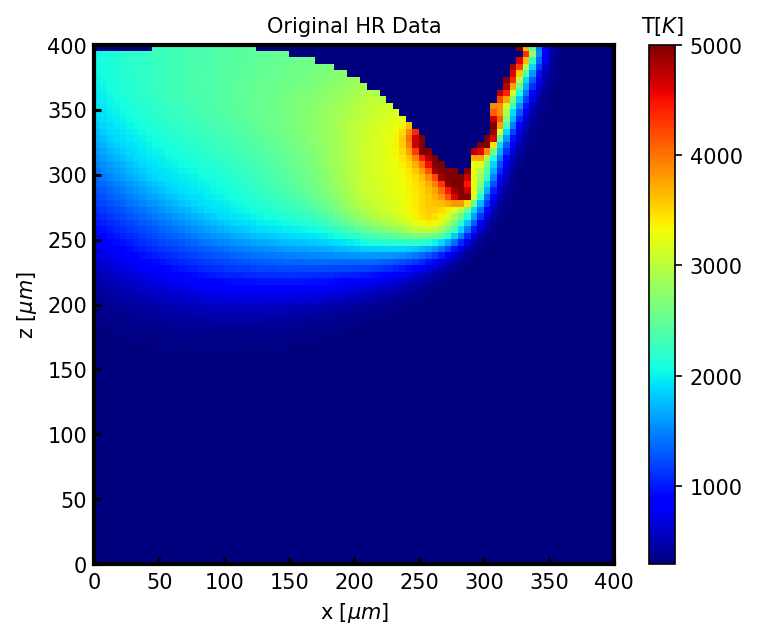

In [12]:
def plt_image(image, dpi= 90, scaling_factor = 1.5, min_temp = 293, max_temp = 5000, title = None):
    plt.figure(dpi = dpi, figsize = np.array([4,3])*scaling_factor)

    plt.imshow(image.T, cmap = 'jet', vmin = min_temp, vmax=max_temp, origin = 'lower',  extent=[0*5,80*5,0*5,80*5])

    plt.xlabel(r'x $[\mu m]$')
    plt.ylabel(r'z $[\mu m]$')
    clb = plt.colorbar()
    clb.ax.set_title(r'T$[K]$',fontsize=10)
    frame_tick()
    plt.title(title, fontsize = 10)
    plt.show()
# for method in ['area', 'lanczos', 'nearest', 'linear', 'cubic']:
#     image = np.load('/home/oogoke/SRdataset/xz_cross_section_data/train/LR/{}/1x/croptempsquarepower365velocity1000_1059.npy'.format(method))
#     plt_image(image, dpi = 150, title = '{}-based 4x downscaling'.format(method))
# for method in ['area', 'lanczos', 'nearest', 'linear', 'cubic']:
image = np.load('/home/oogoke/SRdataset/xz_cross_section_data/train/HR/croptempsquarepower365velocity1000_1059.npy'.format(method))
plt_image(image, dpi = 150,title = 'Original HR Data')

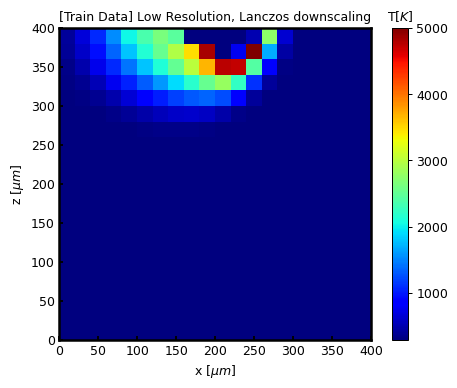

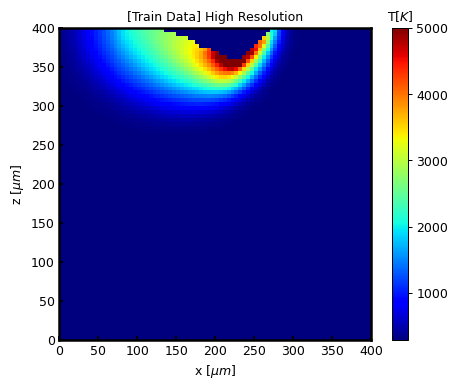

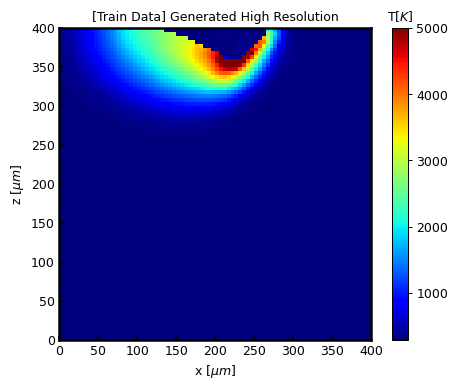

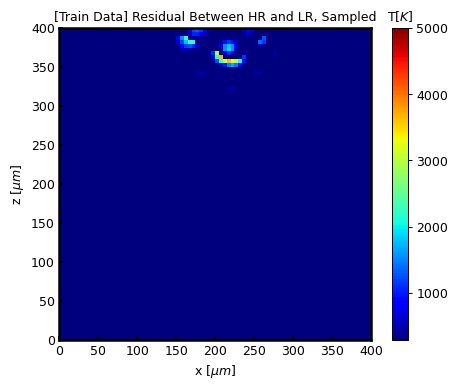

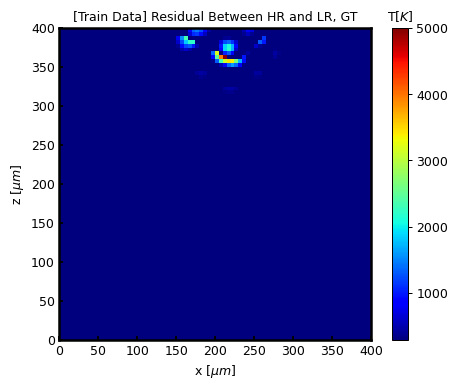

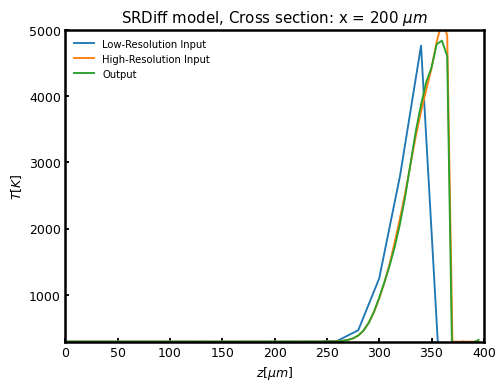

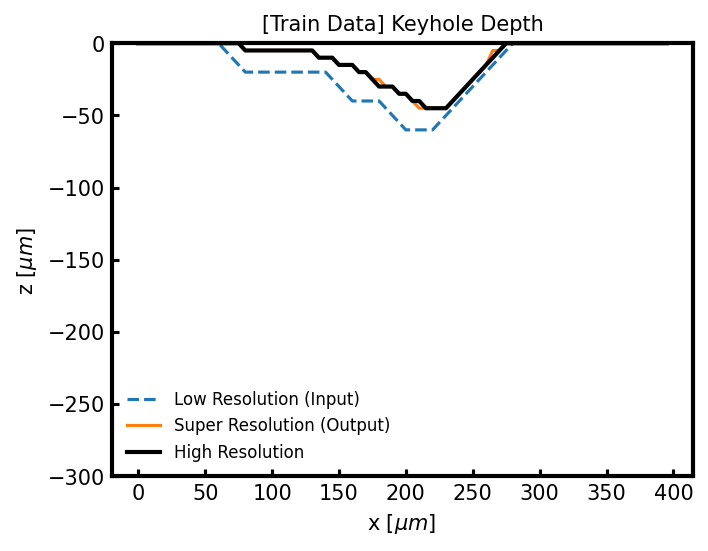

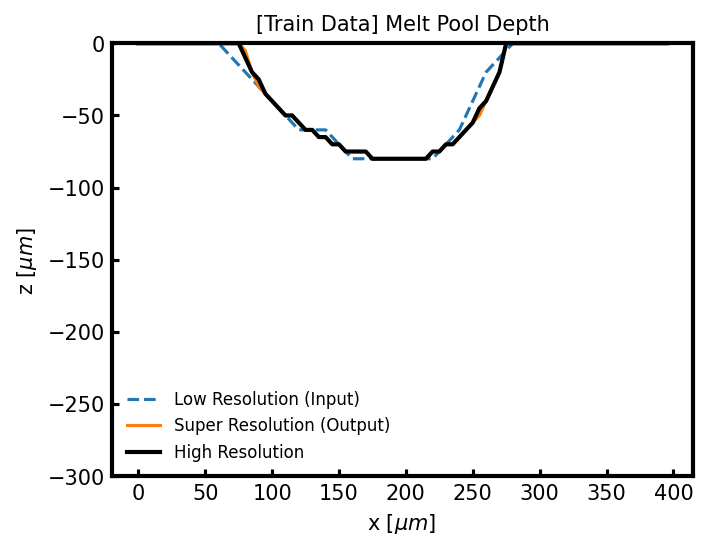

In [8]:
# for epoch in range(140, 150, 2):
parent_directory = '/home/oogoke/SRdataset/testinclonger_epoch_srdiff_attempt_5_add_embed_mean_corrected_5eneg5/'
epoch = 224
# parent_directory = '/home/oogoke/SRdataset/epoch_srdiff_attempt_5_add_embed_mean_corrected_5eneg5/'
data_1 = np.load(os.path.join(parent_directory, 'testall_data-{}.npz').format(epoch))
plot_temp_images_srdiff(data_1)
plot_temp_lines_srdiff(data_1)
plot_srdiff_contours(data_1)



In [19]:
def PSNR(op, t, batch_size): 
    mse = np.sum((t - op) ** 2) 
    #print(mse.size())
    mse /= (batch_size*80*80)

    max_pixel = np.max(t)
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    #print(psnr.size())
    return psnr 
print('LR PSNR: ', PSNR(lr_data, hr, hr.shape[0]))
print('HR PSNR: ',PSNR(generated_hr, hr, hr.shape[0]))


LR PSNR:  49.80645208464533
HR PSNR:  49.518778607525974


In [30]:
from skimage.metrics import structural_similarity as ssim_id
def SSIM(op, t, batch_size):
    ssim = 0 
    for i in range(op.shape[0]):

        # print(out[0,0].size())
        # print(op.shape, t.shape)
        score = ssim_id(op[0], t[0])#, full=True)
        ssim+=score/batch_size
    
        #print("SSIM: {}".format(score))
    return ssim
print('LR SSIM: ',  SSIM(lr_data, hr, hr.shape[0]))
print('SR SSIM: ',  SSIM(generated_hr, hr, hr.shape[0]))



LR SSIM:  0.8817596485529187
SR SSIM:  0.35304429597642695
